In [1]:
import ast
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\bryan\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_da_us= df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_da_us['job_posted_month_no'] = df_da_us['job_posted_date'].dt.month
df_da_us_exploded= df_da_us.explode('job_skills')

In [3]:
df_da_us_pivot=df_da_us_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
df_da_us_pivot.loc['Total'] = df_da_us_pivot.sum()
df_da_us_pivot= df_da_us_pivot[df_da_us_pivot.loc['Total'].sort_values(ascending=False).index]
df_da_us_pivot= df_da_us_pivot.drop('Total')

In [10]:
da_totals= df_da_us.groupby('job_posted_month_no').size()
df_da_us_percent= df_da_us_pivot.div(da_totals/100, axis=0)
df_da_us_percent=df_da_us_percent.reset_index()
df_da_us_percent['job_posted_month'] =df_da_us_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_da_us_percent = df_da_us_percent.set_index('job_posted_month')
df_da_us_percent = df_da_us_percent.drop(columns = 'job_posted_month_no')


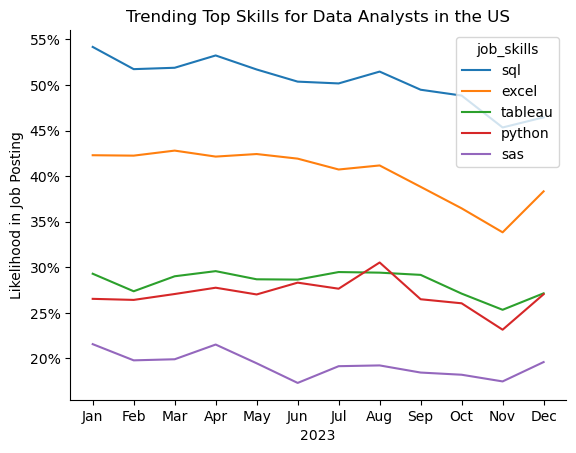

In [25]:
df_plot=df_da_us_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, palette='tab10')
plt.title('Trending Top Skills for Data Analysts in the US')
plt.xlabel('2023')
plt.ylabel('Likelihood in Job Posting')
sns.despine()



from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.show()
